# 📊 Analyse EDA — Concours de Recrutement Publics au Maroc (2021–2025)

---
## ⚙️ ÉTAPE 0 — Imports et configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('✅ Imports réussis')

✅ Imports réussis


---
## ÉTAPE 1 — Chargement des données

In [ ]:
#  Adapte ce chemin selon ton ordinateur
base_path = r"C:\Users\meriem\Desktop\Recrutment\Data Clean"

# Fichier principal (concours)
df = pd.read_csv(
    os.path.join(base_path, 'Maroc_Recrutement_FINAL_2021_2025.csv'),
    encoding='utf-8-sig'
)

# Fichiers complémentaires
df_chomage  = pd.read_csv(os.path.join(base_path, '01_chomage_2021_2024.csv'),  encoding='utf-8-sig')
df_retraite = pd.read_csv(os.path.join(base_path, '02_retraites_REAL_2021_2024.csv'), encoding='utf-8-sig')
df_diplome  = pd.read_csv(os.path.join(base_path, '03_diplomes_2021_2024.csv'), encoding='utf-8-sig')

print(f'📦 Concours : {df.shape[0]:,} lignes, {df.shape[1]} colonnes')
print(f'📦 Chômage  : {df_chomage.shape}')
print(f'📦 Retraite : {df_retraite.shape}')
print(f'📦 Diplômés : {df_diplome.shape}')

📦 Concours : 18,653 lignes, 11 colonnes
📦 Chômage  : (4, 7)
📦 Retraite : (4, 10)
📦 Diplômés : (4, 12)


---
## 🔍 ÉTAPE 2 — Vue d'ensemble de la donnée

In [ ]:
# Types et valeurs manquantes
print('📋 Types des colonnes :')
print(df.dtypes)
print()
print('❓ Valeurs manquantes par colonne :')
print(df.isnull().sum())

📋 Types des colonnes :
Type_Source                 object
Administration              object
عدد المناصب                  int64
Corps                       object
Grade                       object
Nom du poste                object
تاريخ النشر                 object
آخر أجل لإيداع الترشيحات    object
تاريخ الإمتحان              object
Année                        int64
niveau_apres_bac            object
dtype: object

❓ Valeurs manquantes par colonne :
Type_Source                    0
Administration                 0
عدد المناصب                    0
Corps                          0
Grade                          0
Nom du poste                   0
تاريخ النشر                    0
آخر أجل لإيداع الترشيحات    2729
تاريخ الإمتحان              6875
Année                          0
niveau_apres_bac               0
dtype: int64


In [ ]:
# Statistiques descriptives sur le nombre de postes
print('📊 Statistiques sur عدد المناصب (nombre de postes) :')
print(df['عدد المناصب'].describe())

print(f"\ Total postes dans le dataset : {df['عدد المناصب'].sum():,}")
print(f" Années disponibles : {sorted(df['Année'].dropna().unique())}")

📊 Statistiques sur عدد المناصب (nombre de postes) :
count    18653.000000
mean        13.278507
std        158.060475
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max      11400.000000
Name: عدد المناصب, dtype: float64

🔢 Total postes dans le dataset : 247,684
📅 Années disponibles : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


---
## 📈 ÉTAPE 3 — KPI 1 : Volume de recrutement par année

In [ ]:
# Filtrer 2021-2025 uniquement
df_filtered = df[df['Année'].isin([2021, 2022, 2023, 2024, 2025])].copy()

# --- Nombre de concours (lignes) par année ---
nb_concours = df_filtered.groupby('Année').size().reset_index(name='Nb_Concours')

# --- Nombre de postes par année ---
nb_postes = df_filtered.groupby('Année')['عدد المناصب'].sum().reset_index(name='Nb_Postes')

kpi_annee = nb_concours.merge(nb_postes, on='Année')
print('📊 Volume de recrutement par année :')
print(kpi_annee.to_string(index=False))

📊 Volume de recrutement par année :
 Année  Nb_Concours  Nb_Postes
  2021         2827      43894
  2022         3112      49969
  2023         4224      57963
  2024         5052      57826
  2025         3438      38032


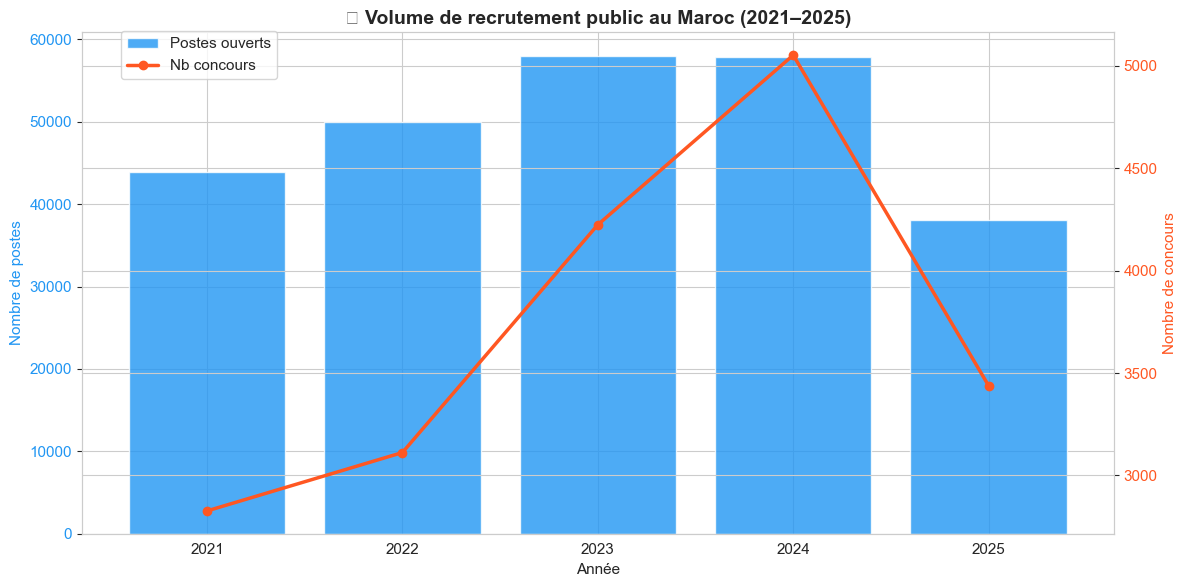

✅ Graphique sauvegardé : graph_01_volume_annee.png


In [ ]:
# --- Graphique : postes ET concours par année ---
fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = '#2196F3'
ax1.bar(kpi_annee['Année'].astype(str), kpi_annee['Nb_Postes'], color=color1, alpha=0.8, label='Postes ouverts')
ax1.set_xlabel('Année')
ax1.set_ylabel('Nombre de postes', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = '#FF5722'
ax2.plot(kpi_annee['Année'].astype(str), kpi_annee['Nb_Concours'], color=color2, marker='o', linewidth=2.5, label='Nb concours')
ax2.set_ylabel('Nombre de concours', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('📈 Volume de recrutement public au Maroc (2021–2025)', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'graph_01_volume_annee.png'), dpi=150)
plt.show()
print('✅ Graphique sauvegardé : graph_01_volume_annee.png')

---
## 🏛️ ÉTAPE 4 — KPI 2 : Top 10 administrations les plus recruteuses

In [ ]:
top_admin = (
    df_filtered
    .groupby('Administration')['عدد المناصب']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_admin.columns = ['Administration', 'Total_Postes']

print('🏆 Top 10 administrations par nombre de postes :')
print(top_admin.to_string(index=False))

🏆 Top 10 administrations par nombre de postes :
                                                                                         Administration  Total_Postes
Ministère de l’Education nationale, du Préscolaire et des Sports - Département de l’Education nationale         44885
                                   Ministère de l’intérieur -Direction Générale de la Sûreté Nationale-         33953
                                                      Ministère de la Santé et de la Protection sociale         28366
                                   Office de la Formation Professionnelle et de la Promotion du Travail         11296
              Académie Régionale de l’Education et de la Formation de la région Grand Casablanca Settat          7152
                                                                Ministère de l’Économie et des Finances          6984
                                                                               Ministère de l’intérieur          5881
        

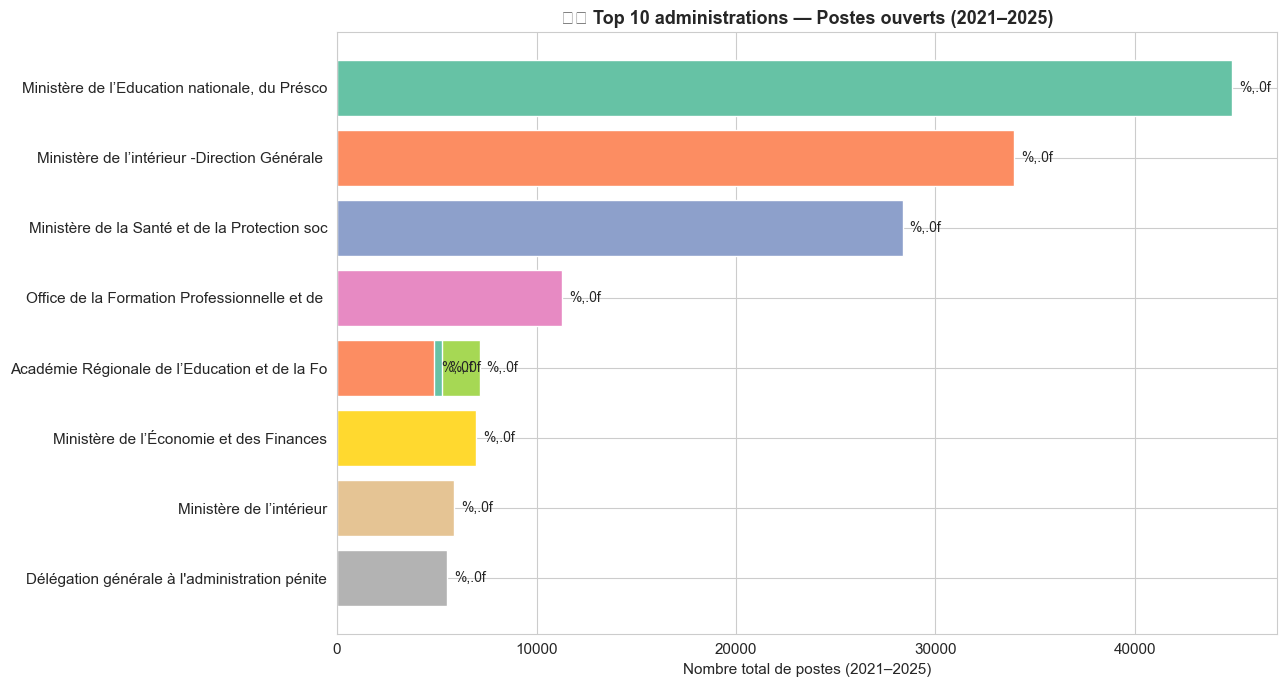

✅ Graphique sauvegardé : graph_02_top_admin.png


In [ ]:
# Graphique barh
fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(
    top_admin['Administration'].str[:45],  # Tronquer si trop long
    top_admin['Total_Postes'],
    color=sns.color_palette('Set2', 10)
)
ax.bar_label(bars, fmt='%,.0f', padding=5, fontsize=10)
ax.set_xlabel('Nombre total de postes (2021–2025)')
ax.set_title('🏛️ Top 10 administrations — Postes ouverts (2021–2025)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'graph_02_top_admin.png'), dpi=150)
plt.show()
print('✅ Graphique sauvegardé : graph_02_top_admin.png')

---
## 🗂️ ÉTAPE 5 — KPI 3 : Répartition par type de source

📂 Répartition des postes par type de source :
Type_Source
Ministère        142885
Établissement     98667
Collectivité       6047
Expert               85
Name: عدد المناصب, dtype: int64


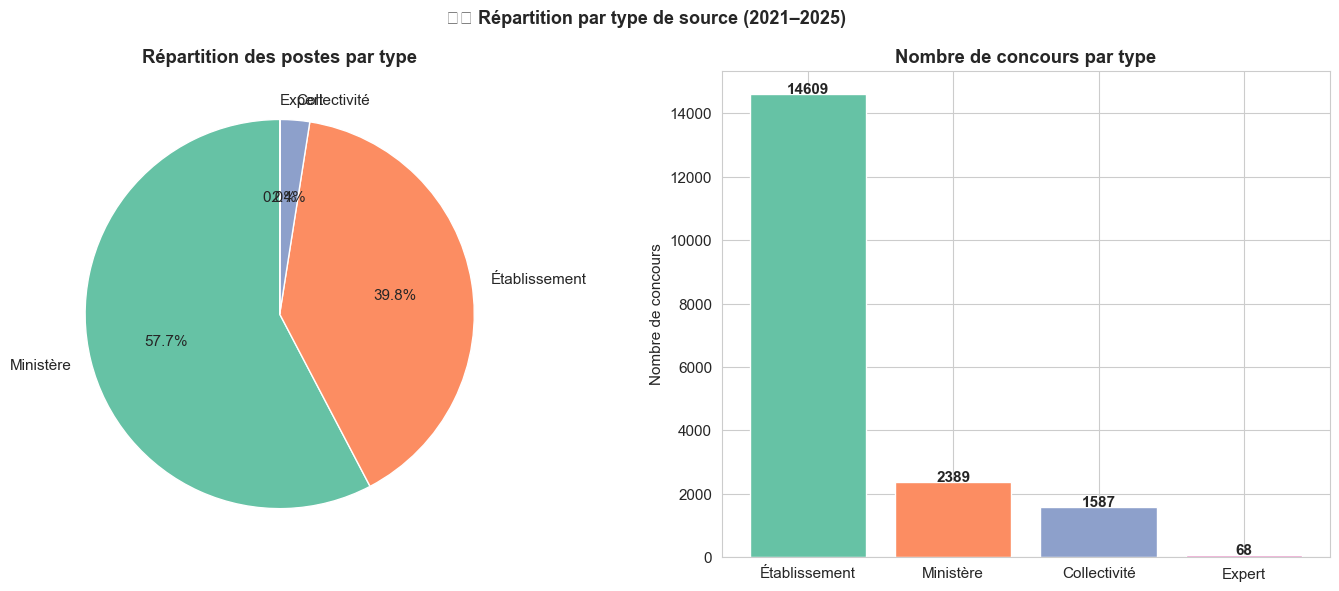

In [ ]:
# Postes par type (Ministère, Collectivité, Établissement, Expert)
type_postes = (
    df_filtered
    .groupby('Type_Source')['عدد المناصب']
    .sum()
    .sort_values(ascending=False)
)

print('📂 Répartition des postes par type de source :')
print(type_postes)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart — postes
axes[0].pie(
    type_postes.values,
    labels=type_postes.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2', len(type_postes))
)
axes[0].set_title('Répartition des postes par type', fontweight='bold')

# Bar chart — concours
type_concours = df_filtered.groupby('Type_Source').size().sort_values(ascending=False)
axes[1].bar(type_concours.index, type_concours.values, color=sns.color_palette('Set2', len(type_concours)))
axes[1].set_title('Nombre de concours par type', fontweight='bold')
axes[1].set_ylabel('Nombre de concours')
for i, v in enumerate(type_concours.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('🗂️ Répartition par type de source (2021–2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'graph_03_type_source.png'), dpi=150)
plt.show()

---
## 🎓 ÉTAPE 6 — KPI 4 : Répartition par niveau d'études (BAC+)

In [ ]:
# Postes par niveau BAC+
niveau_postes = (
    df_filtered
    .groupby('niveau_apres_bac')['عدد المناصب']
    .sum()
    .sort_values(ascending=False)
)

print('🎓 Postes par niveau d\'études :')
print(niveau_postes)
print(f"\nTotal : {niveau_postes.sum():,} postes")

🎓 Postes par niveau d'études :
niveau_apres_bac
Non classifié       130962
Bac                  31744
Bac+2                26623
Bac+3                25891
Bac+5                16679
Bac+7 (Doctorat)     10871
Doctorat (Bac+8)      4914
Name: عدد المناصب, dtype: int64

Total : 247,684 postes


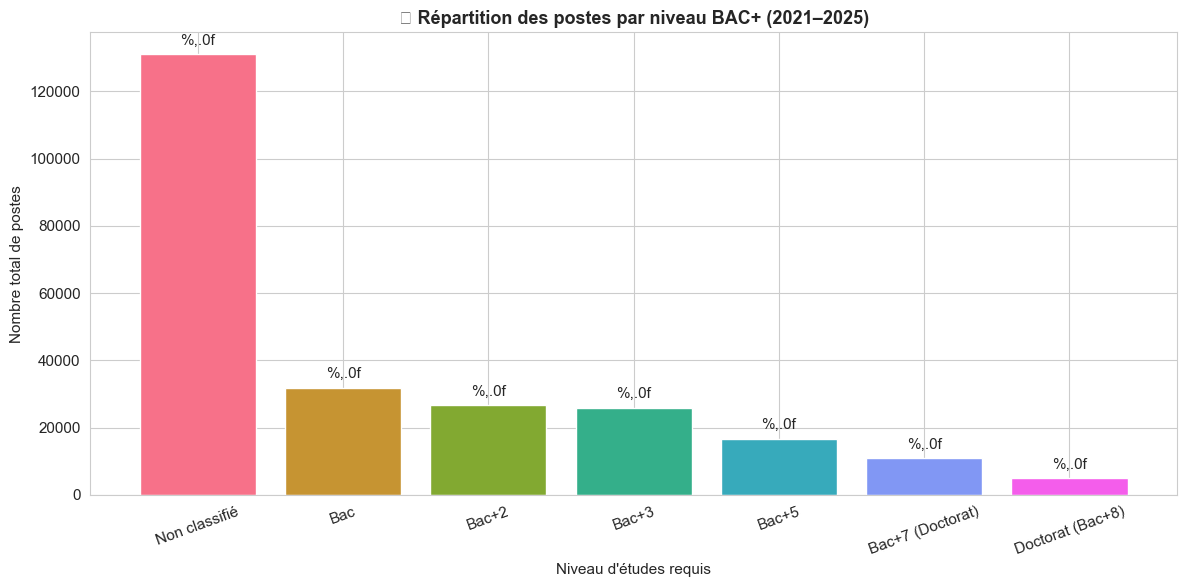

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('husl', len(niveau_postes))
bars = ax.bar(niveau_postes.index, niveau_postes.values, color=colors)
ax.bar_label(bars, fmt='%,.0f', padding=5)
ax.set_xlabel('Niveau d\'études requis')
ax.set_ylabel('Nombre total de postes')
ax.set_title('🎓 Répartition des postes par niveau BAC+ (2021–2025)', fontsize=13, fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'graph_04_niveau_bac.png'), dpi=150)
plt.show()

---
## 📉 ÉTAPE 7 — KPI 5 : Taux d'évolution annuelle des postes

📉 Taux d'évolution annuelle des postes :
 Année  Nb_Postes  Taux_Evolution_%
  2021      43894               NaN
  2022      49969              13.8
  2023      57963              16.0
  2024      57826              -0.2
  2025      38032             -34.2


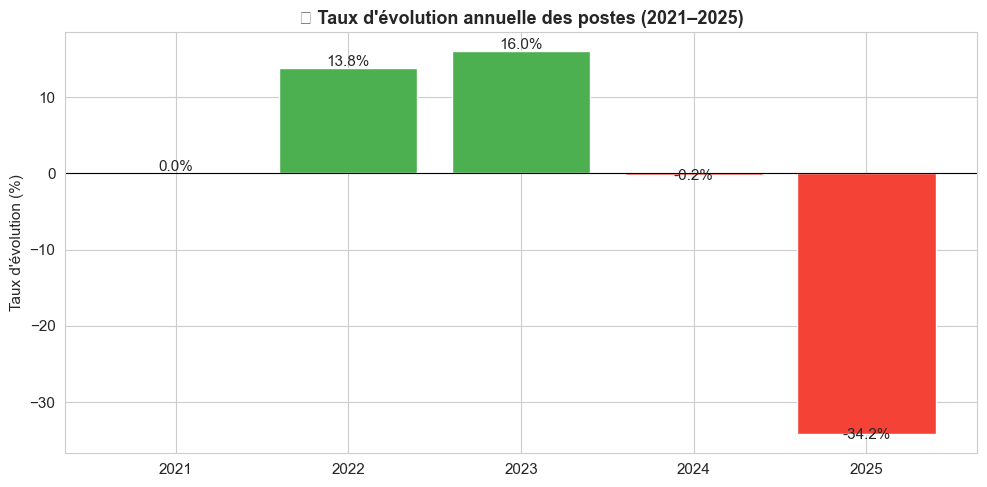

In [ ]:
# Calcul du taux d'évolution d'une année à l'autre
evolution = kpi_annee.copy()
evolution['Taux_Evolution_%'] = evolution['Nb_Postes'].pct_change() * 100
evolution['Taux_Evolution_%'] = evolution['Taux_Evolution_%'].round(1)

print('📉 Taux d\'évolution annuelle des postes :')
print(evolution[['Année', 'Nb_Postes', 'Taux_Evolution_%']].to_string(index=False))

# Graphique
fig, ax = plt.subplots(figsize=(10, 5))
couleurs = ['#4CAF50' if x >= 0 else '#F44336' for x in evolution['Taux_Evolution_%'].fillna(0)]
ax.bar(evolution['Année'].astype(str), evolution['Taux_Evolution_%'].fillna(0), color=couleurs)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Taux d\'évolution (%)')
ax.set_title('📉 Taux d\'évolution annuelle des postes (2021–2025)', fontsize=13, fontweight='bold')
for i, (annee, val) in enumerate(zip(evolution['Année'].astype(str), evolution['Taux_Evolution_%'].fillna(0))):
    ax.text(i, val + (0.3 if val >= 0 else -0.7), f'{val:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'graph_05_evolution.png'), dpi=150)
plt.show()

---
## ⚖️ ÉTAPE 8 — KPI 6 : Comparaisons structurelles
### Postes ouverts vs Diplômés vs Départs à la retraite vs Taux de chômage

In [ ]:
# --- Préparer les postes par année (2021-2024 uniquement pour comparer) ---
postes_21_24 = (
    df_filtered[df_filtered['Année'].isin([2021, 2022, 2023, 2024])]
    .groupby('Année')['عدد المناصب']
    .sum()
    .reset_index()
    .rename(columns={'عدد المناصب': 'Postes_Ouverts'})
)

# --- Fusion de toutes les sources ---
compare = postes_21_24.merge(df_diplome[['Année', 'Nouveaux_Diplômés']], on='Année', how='left')
compare = compare.merge(df_retraite[['Année', 'Départs_Total']], on='Année', how='left')
compare = compare.merge(df_chomage[['Année', 'Total_National']], on='Année', how='left')
compare.rename(columns={'Total_National': 'Taux_Chomage_%'}, inplace=True)

# Ratio postes / diplômés
compare['Ratio_Postes_Diplômés_%'] = (compare['Postes_Ouverts'] / compare['Nouveaux_Diplômés'] * 100).round(1)

print('⚖️ Tableau comparatif (2021–2024) :')
print(compare.to_string(index=False))

⚖️ Tableau comparatif (2021–2024) :
 Année  Postes_Ouverts  Nouveaux_Diplômés  Départs_Total  Taux_Chomage_%  Ratio_Postes_Diplômés_%
  2021           43894             145000          14722            12.3                     30.3
  2022           49969             148000          14654            11.8                     33.8
  2023           57963             151000          14195            13.0                     38.4
  2024           57826             153000          13689            13.3                     37.8


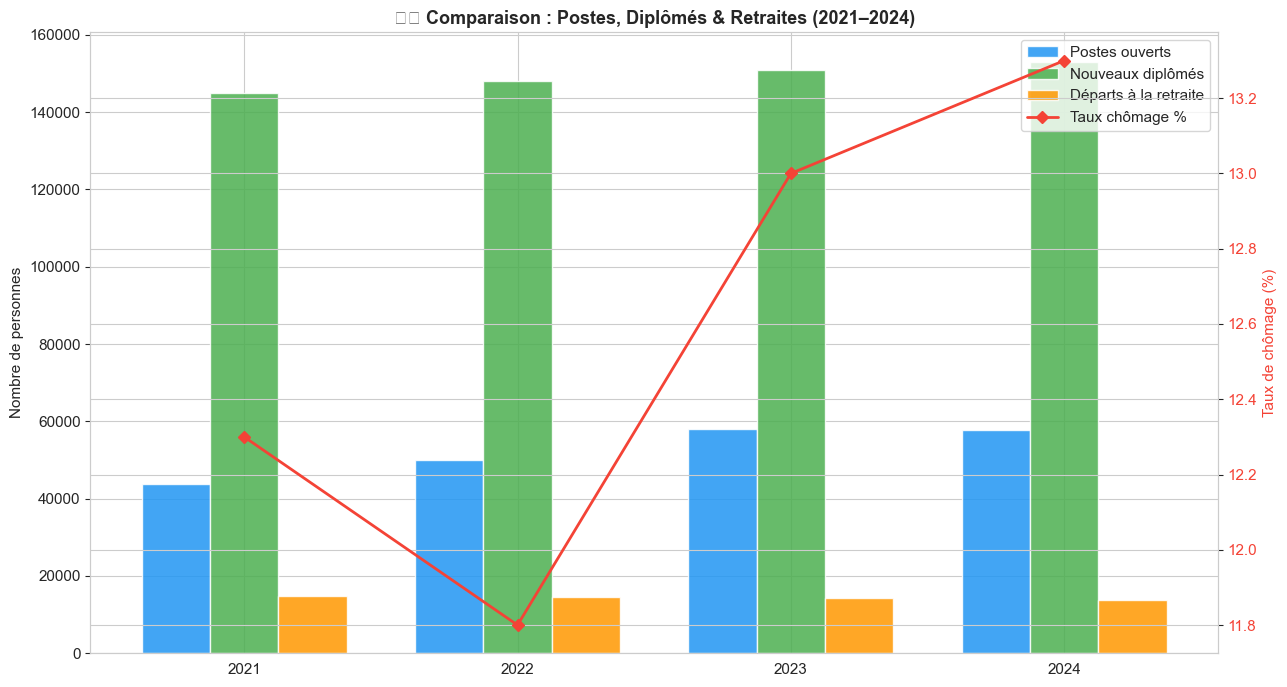

✅ Graphique sauvegardé : graph_06_comparaison_structurelle.png


In [ ]:
# --- Graphique : Postes vs Diplômés vs Retraites ---
fig, ax1 = plt.subplots(figsize=(13, 7))

x = compare['Année'].astype(str)
width = 0.25
x_idx = np.arange(len(x))

ax1.bar(x_idx - width, compare['Postes_Ouverts'], width, label='Postes ouverts', color='#2196F3', alpha=0.85)
ax1.bar(x_idx,         compare['Nouveaux_Diplômés'], width, label='Nouveaux diplômés', color='#4CAF50', alpha=0.85)
ax1.bar(x_idx + width, compare['Départs_Total'],     width, label='Départs à la retraite', color='#FF9800', alpha=0.85)

ax1.set_xticks(x_idx)
ax1.set_xticklabels(x)
ax1.set_ylabel('Nombre de personnes')
ax1.set_title('⚖️ Comparaison : Postes, Diplômés & Retraites (2021–2024)', fontsize=13, fontweight='bold')

# Axe secondaire : taux de chômage
ax2 = ax1.twinx()
ax2.plot(x_idx, compare['Taux_Chomage_%'], color='#F44336', marker='D', linewidth=2, label='Taux chômage %')
ax2.set_ylabel('Taux de chômage (%)', color='#F44336')
ax2.tick_params(axis='y', labelcolor='#F44336')

# Légendes combinées
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(base_path, 'graph_06_comparaison_structurelle.png'), dpi=150)
plt.show()
print('✅ Graphique sauvegardé : graph_06_comparaison_structurelle.png')

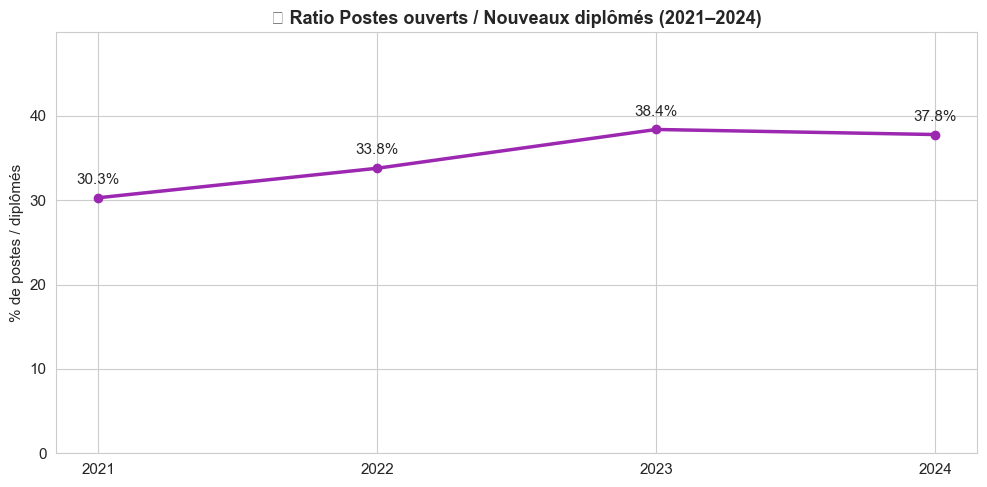

In [ ]:
# --- Graphique : Ratio postes / diplômés ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(compare['Année'].astype(str), compare['Ratio_Postes_Diplômés_%'],
        marker='o', color='#9C27B0', linewidth=2.5)
for i, row in compare.iterrows():
    ax.annotate(f"{row['Ratio_Postes_Diplômés_%']:.1f}%",
                xy=(str(int(row['Année'])), row['Ratio_Postes_Diplômés_%']),
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=11)
ax.set_ylabel('% de postes / diplômés')
ax.set_title('🎯 Ratio Postes ouverts / Nouveaux diplômés (2021–2024)', fontsize=13, fontweight='bold')
ax.set_ylim(0, compare['Ratio_Postes_Diplômés_%'].max() * 1.3)
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'graph_07_ratio_postes_diplomes.png'), dpi=150)
plt.show()

---
## 💾 ÉTAPE 9 — Export des résultats

In [ ]:
# Export du tableau KPI principal
kpi_final_path = os.path.join(base_path, 'KPI_resultats.csv')
compare.to_csv(kpi_final_path, index=False, encoding='utf-8-sig')
print(f'✅ KPIs exportés : {kpi_final_path}')

# Export du tableau par année
evolution_path = os.path.join(base_path, 'KPI_evolution_annee.csv')
evolution.to_csv(evolution_path, index=False, encoding='utf-8-sig')
print(f'✅ Évolution exportée : {evolution_path}')

# Export du top administrations
top_admin_path = os.path.join(base_path, 'KPI_top_admin.csv')
top_admin.to_csv(top_admin_path, index=False, encoding='utf-8-sig')
print(f'✅ Top admins exporté : {top_admin_path}')

print('\n🎉 Analyse EDA terminée avec succès !')
print('📁 Fichiers générés dans :', base_path)

✅ KPIs exportés : C:\Users\meriem\Desktop\Recrutment\Data Clean\KPI_resultats.csv
✅ Évolution exportée : C:\Users\meriem\Desktop\Recrutment\Data Clean\KPI_evolution_annee.csv
✅ Top admins exporté : C:\Users\meriem\Desktop\Recrutment\Data Clean\KPI_top_admin.csv

🎉 Analyse EDA terminée avec succès !
📁 Fichiers générés dans : C:\Users\meriem\Desktop\Recrutment\Data Clean
